In [4]:
!pip install -q scanpy squidpy matplotlib openpyxl

In [5]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings('ignore')
sc.set_figure_params(dpi=100, facecolor='white')

os.makedirs('figures', exist_ok=True)

In [6]:
!curl -O https://cf.10xgenomics.com/samples/xenium/1.0.1/Xenium_FFPE_Human_Breast_Cancer_Rep1/Xenium_FFPE_Human_Breast_Cancer_Rep1_cell_feature_matrix.h5

!curl -O https://cf.10xgenomics.com/samples/xenium/1.0.1/Xenium_FFPE_Human_Breast_Cancer_Rep1/Xenium_FFPE_Human_Breast_Cancer_Rep1_cells.csv.gz

!curl -O https://cf.10xgenomics.com/samples/xenium/1.0.1/Xenium_FFPE_Human_Breast_Cancer_Rep1/Cell_Barcode_Type_Matrices.xlsx

print("Downloads complete.")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 11.5M  100 11.5M    0     0  9514k      0  0:00:01  0:00:01 --:--:-- 9521k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 7744k  100 7744k    0     0  10.4M      0 --:--:-- --:--:-- --:--:-- 10.4M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   111    0   111    0     0    260      0 --:--:-- --:--:-- --:--:--   260
Downloads complete.


In [7]:
print(os.listdir())

['.config', 'figures', 'Xenium_FFPE_Human_Breast_Cancer_Rep1_cell_feature_matrix.h5', 'Xenium_FFPE_Human_Breast_Cancer_Rep1_cells.csv.gz', 'Cell_Barcode_Type_Matrices.xlsx', 'sample_data']


In [8]:
adata = sc.read_10x_h5(
    'Xenium_FFPE_Human_Breast_Cancer_Rep1_cell_feature_matrix.h5'
)

adata.var_names_make_unique()

print(f"Cells: {adata.n_obs}")
print(f"Genes: {adata.n_vars}")

Cells: 167780
Genes: 313


In [9]:
cells_df = pd.read_csv(
    'Xenium_FFPE_Human_Breast_Cancer_Rep1_cells.csv.gz'
)

print(cells_df.head())
print(cells_df.columns)

   cell_id  x_centroid  y_centroid  transcript_counts  control_probe_counts  \
0        1  847.259912  326.191365                 28                     1   
1        2  826.341995  328.031830                 94                     0   
2        3  848.766919  331.743187                  9                     0   
3        4  824.228409  334.252643                 11                     0   
4        5  841.357538  332.242505                 48                     0   

   control_codeword_counts  total_counts   cell_area  nucleus_area  
0                        0            29   58.387031     26.642187  
1                        0            94  197.016719     42.130781  
2                        0             9   16.256250     12.688906  
3                        0            11   42.311406     10.069844  
4                        0            48  107.652500     37.479687  
Index(['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'control_code

In [10]:
print(cells_df.columns.tolist())

['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area']


In [11]:
cells_df = cells_df.set_index('cell_id')

adata.obs['x'] = adata.obs_names.map(cells_df['x_centroid'])
adata.obs['y'] = adata.obs_names.map(cells_df['y_centroid'])

adata = adata[adata.obs['x'].notna()].copy()

adata.obsm['spatial'] = adata.obs[['x', 'y']].values

print(f"Cells with coordinates: {adata.n_obs}")

Cells with coordinates: 0


In [13]:
import os

for f in os.listdir():
    print(f)

.config
figures
Xenium_FFPE_Human_Breast_Cancer_Rep1_cell_feature_matrix.h5
Xenium_FFPE_Human_Breast_Cancer_Rep1_cells.csv.gz
Cell_Barcode_Type_Matrices.xlsx
sample_data


In [14]:
!ls -lh Cell_Barcode_Type_Matrices.xlsx

-rw-r--r-- 1 root root 111 Jun  2 04:32 Cell_Barcode_Type_Matrices.xlsx


In [15]:
!head -n 5 Cell_Barcode_Type_Matrices.xlsx

<?xml version="1.0" encoding="UTF-8"?>
<Error><Code>AccessDenied</Code><Message>Access Denied</Message></Error>

In [16]:
!file Cell_Barcode_Type_Matrices.xlsx

Cell_Barcode_Type_Matrices.xlsx: XML 1.0 document, ASCII text


In [18]:
!curl -L -o Cell_Barcode_Type_Matrices.xlsx \
https://cf.10xgenomics.com/samples/xenium/1.0.1/Xenium_FFPE_Human_Breast_Cancer_Rep1/analysis/Cell_Barcode_Type_Matrices.xlsx

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   111    0   111    0     0    257      0 --:--:-- --:--:-- --:--:--   257


In [19]:
import os
print(os.listdir())

['.config', 'figures', 'Xenium_FFPE_Human_Breast_Cancer_Rep1_cell_feature_matrix.h5', 'Xenium_FFPE_Human_Breast_Cancer_Rep1_cells.csv.gz', 'Cell_Barcode_Type_Matrices.xlsx', 'sample_data']


In [21]:
!rm Cell_Barcode_Type_Matrices.xlsx

In [22]:
adata

AnnData object with n_obs × n_vars = 0 × 313
    obs: 'x', 'y'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

In [23]:
adata.n_obs, adata.n_vars

(0, 313)

In [24]:
adata.obsm

AxisArrays with keys: spatial

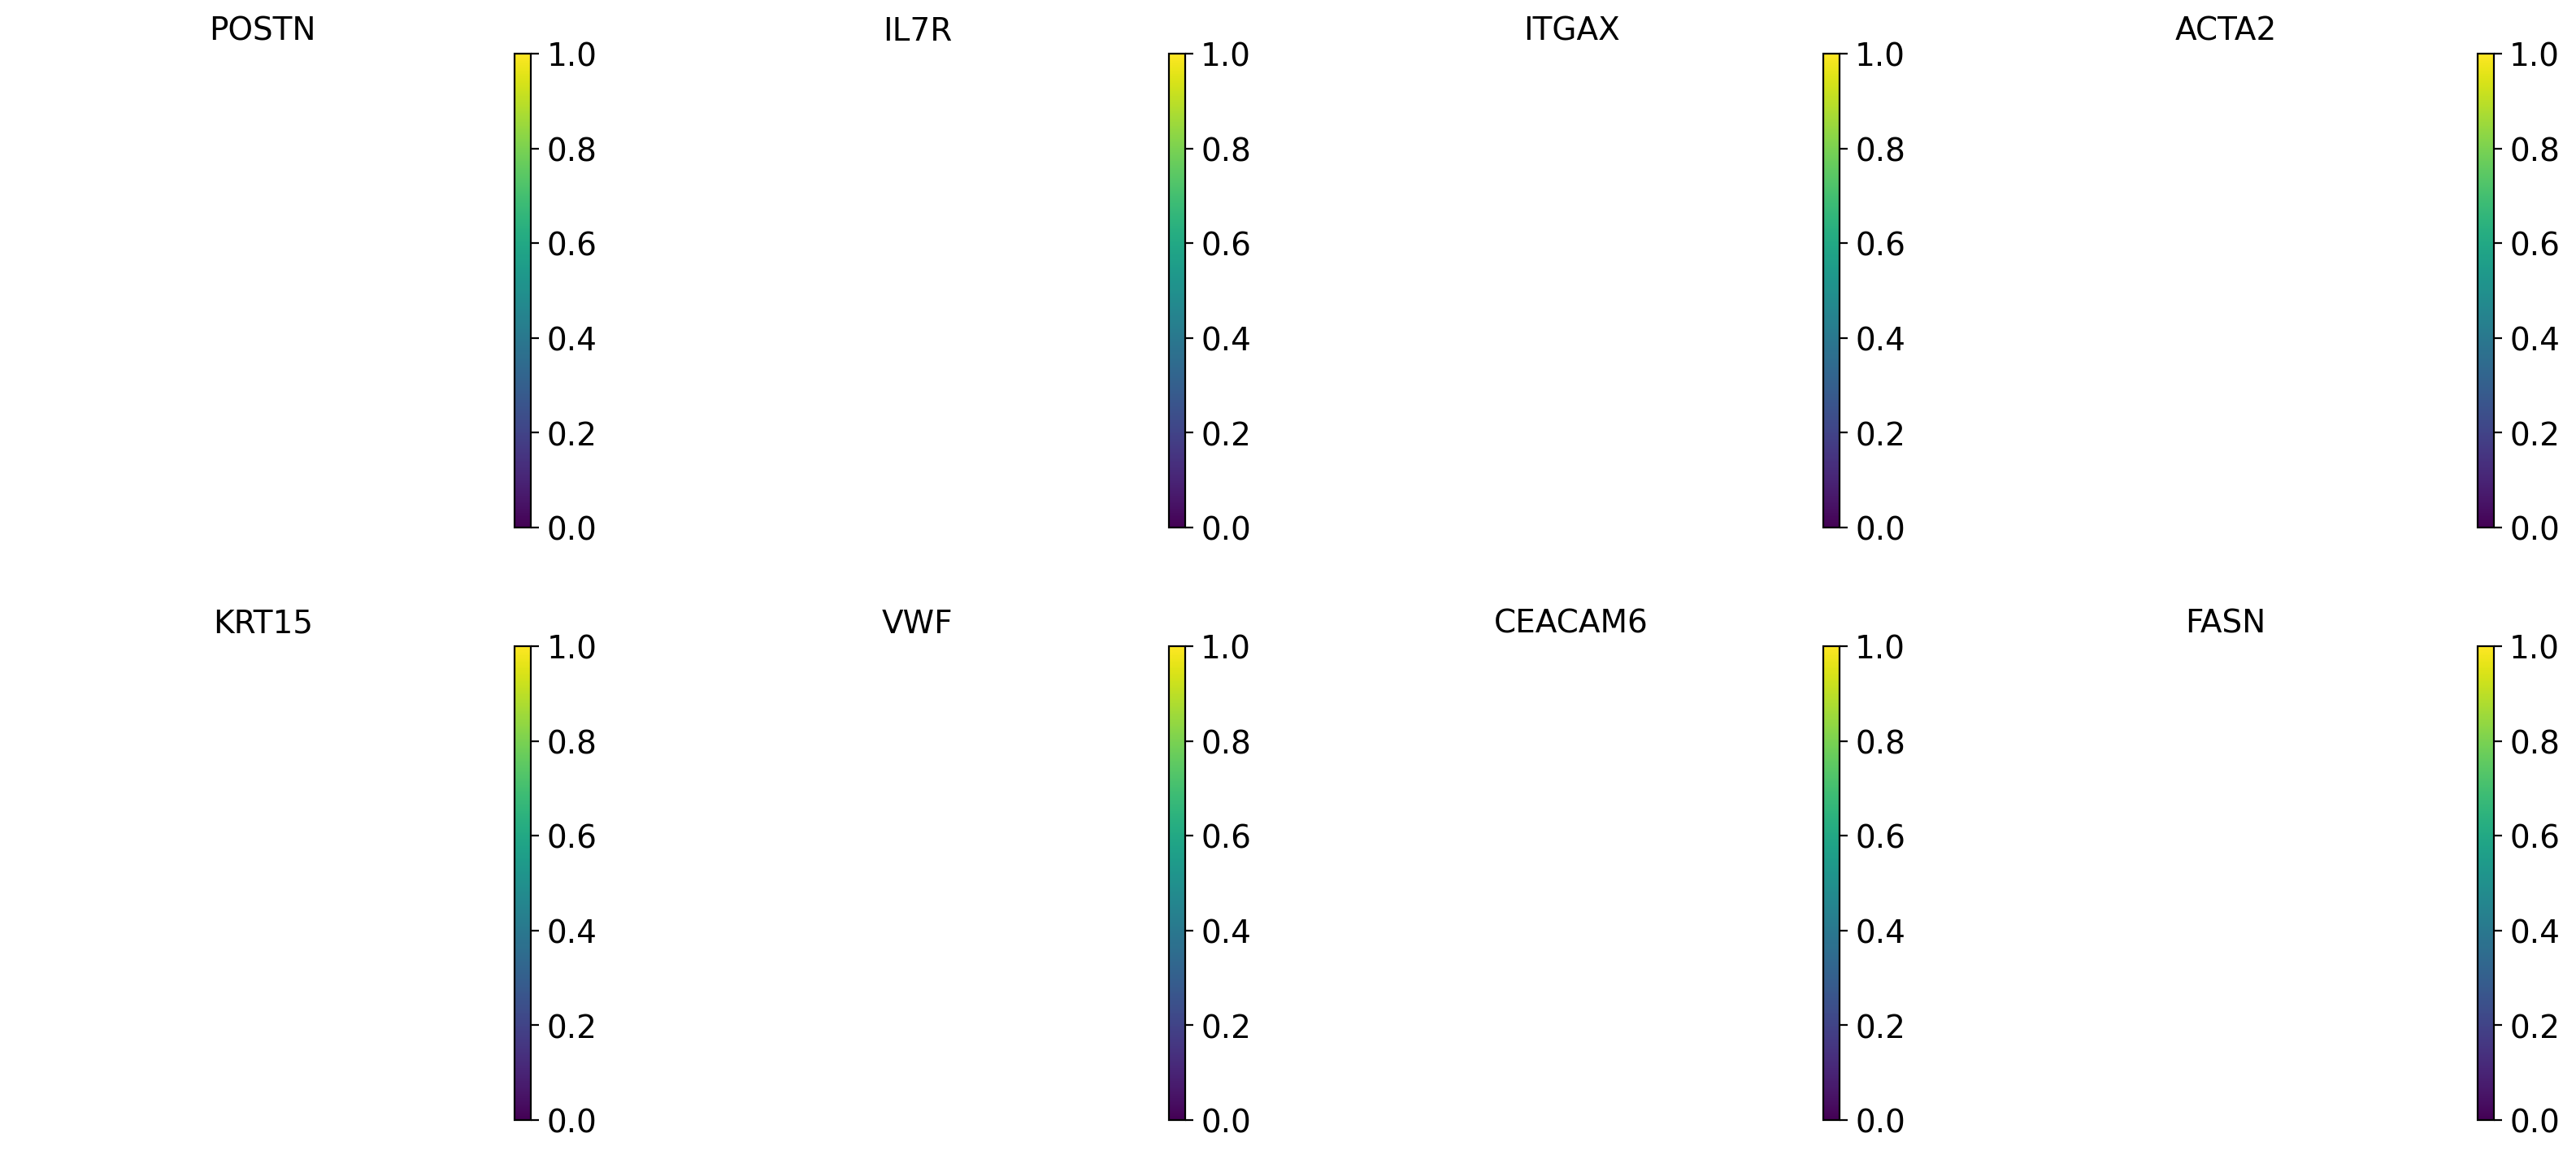

In [25]:
genes_figure3b = [
    "POSTN", "IL7R", "ITGAX", "ACTA2",
    "KRT15", "VWF", "CEACAM6", "FASN"
]

sc.pl.embedding(
    adata,
    basis="spatial",
    color=genes_figure3b,
    ncols=4,
    size=0.3,
    frameon=False
)

In [26]:
plt.savefig("figure3b_reproduction.png", dpi=300, bbox_inches="tight")

<Figure size 400x400 with 0 Axes>